# Clasificación de audio con LSTM en Keras

## Objetivo

En este notebook veremos una aplicación adicional de modelos secuenciales: clasificación de audio.

La idea general será:

- cargar audios cortos,
- transformarlos a espectrogramas,
- interpretar cada espectrograma como una secuencia,
- y entrenar una red `LSTM` para clasificar comandos de voz simples.

> En este contexto, cada paso temporal de la secuencia contendrá información de frecuencias del audio.

In [1]:
import os
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


## 1. Descargar un dataset de comandos de voz

Usaremos el dataset **mini speech commands** disponible en TensorFlow.

Contiene audios cortos asociados a palabras como:

- `yes`
- `no`
- `go`
- `stop`
- `up`
- `down`
- `left`
- `right`

In [2]:
data_dir = tf.keras.utils.get_file(
    "mini_speech_commands.zip",
    origin="http://storage.googleapis.com/download.tensorflow.org/data/mini_speech_commands.zip",
    extract=True,
    cache_dir=".",
    cache_subdir="data"
)

data_dir = pathlib.Path(str(data_dir)).with_suffix("")
print("Ruta inicial:", data_dir)
print("Contenido inicial:", tf.io.gfile.listdir(str(data_dir)))

182082353/182082353 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
Ruta inicial: data/mini_speech_commands_extracted
Contenido inicial: ['mini_speech_commands', '__MACOSX']


In [3]:
data_dir = data_dir / "mini_speech_commands"

commands = np.array(tf.io.gfile.listdir(str(data_dir)))
commands = commands[(commands != "README.md") & (commands != ".DS_Store")]

print("Ruta final:", data_dir)
print("Clases:")
print(commands)

Ruta final: data/mini_speech_commands_extracted/mini_speech_commands
Clases:
['no' 'stop' 'go' 'yes' 'right' 'down' 'up' 'left']


## 2. Crear conjuntos de entrenamiento y validación

Usaremos `audio_dataset_from_directory`, que simplifica mucho la carga de archivos `.wav`.

In [4]:
seed = 42
batch_size = 32

train_ds, val_ds = tf.keras.utils.audio_dataset_from_directory(
    directory=data_dir,
    batch_size=batch_size,
    validation_split=0.2,
    seed=seed,
    output_sequence_length=16000,
    subset="both"
)

Found 8000 files belonging to 8 classes.
Using 6400 files for training.
Using 1600 files for validation.


In [5]:
label_names = np.array(train_ds.class_names)
print("Etiquetas:", label_names)

Etiquetas: ['down' 'go' 'left' 'no' 'right' 'stop' 'up' 'yes']


In [6]:
for audio_batch, label_batch in train_ds.take(1):
    print("Shape batch de audio :", audio_batch.shape)
    print("Shape batch de labels:", label_batch.shape)

Shape batch de audio : (32, 16000, 1)
Shape batch de labels: (32,)


### Observación

Cada audio fue ajustado a longitud fija `16000`.

Eso corresponde, aproximadamente, a 1 segundo de audio muestreado a 16 kHz.

## 3. Visualizar un audio de ejemplo

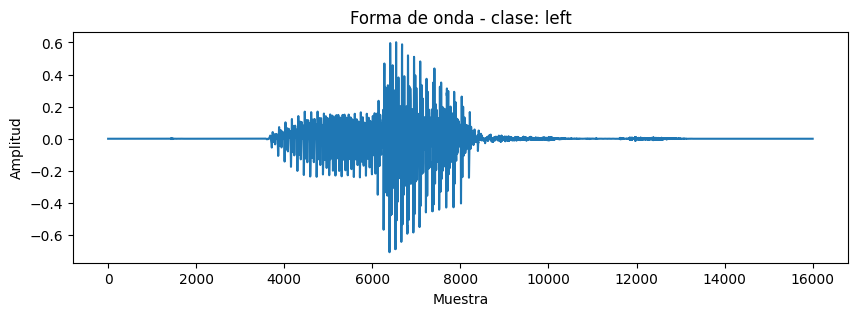

In [7]:
audio = audio_batch[0]
label = label_batch[0]

plt.figure(figsize=(10, 3))
plt.plot(audio.numpy())
plt.title(f"Forma de onda - clase: {label_names[label]}")
plt.xlabel("Muestra")
plt.ylabel("Amplitud")
plt.show()

### Escuchar el audio

Además de ver la forma de onda, también podemos escuchar el audio correspondiente.

In [8]:
from IPython.display import Audio

Audio(audio.numpy().squeeze(), rate=16000)

## 4. De audio a espectrograma

No trabajaremos directamente con la onda cruda.

En cambio, convertiremos cada audio a un **espectrograma**, que resume cómo cambia el contenido en frecuencia a lo largo del tiempo.

Eso nos permite interpretar cada ejemplo como una **secuencia de vectores**.

In [9]:
def get_spectrogram(waveform):
    spectrogram = tf.signal.stft(
        waveform,
        frame_length=256,
        frame_step=128
    )
    spectrogram = tf.abs(spectrogram)
    return spectrogram

In [10]:
print("Shape del audio original:", audio.shape)

Shape del audio original: (16000, 1)


In [11]:
audio = tf.squeeze(audio, axis=-1)
spectrogram = get_spectrogram(audio)

print("Shape del espectrograma:", spectrogram.shape)

Shape del espectrograma: (124, 129)


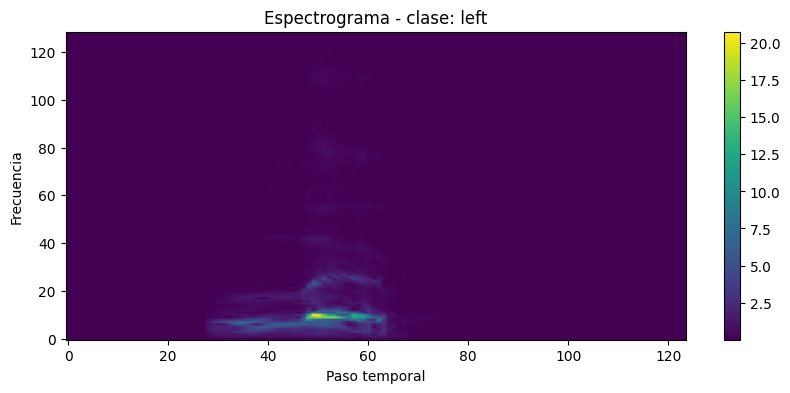

In [12]:
plt.figure(figsize=(10, 4))
plt.imshow(
    tf.transpose(spectrogram).numpy(),
    aspect="auto",
    origin="lower"
)
plt.title(f"Espectrograma - clase: {label_names[label]}")
plt.xlabel("Paso temporal")
plt.ylabel("Frecuencia")
plt.colorbar()
plt.show()

### Idea clave

El espectrograma puede verse como una secuencia donde:

- el eje horizontal representa el tiempo,
- y en cada instante tenemos un vector de intensidades en distintas frecuencias.

Eso encaja muy bien con una `LSTM`.

## 5. Preparar los datasets de espectrogramas

In [13]:
def waveform_to_spectrogram(audio, label):
    audio = tf.squeeze(audio, axis=-1)
    spectrogram = get_spectrogram(audio)
    return spectrogram, label

In [14]:
train_spectrogram_ds = train_ds.map(waveform_to_spectrogram, num_parallel_calls=tf.data.AUTOTUNE)
val_spectrogram_ds   = val_ds.map(waveform_to_spectrogram, num_parallel_calls=tf.data.AUTOTUNE)

In [15]:
train_spectrogram_ds = train_spectrogram_ds.prefetch(tf.data.AUTOTUNE)
val_spectrogram_ds   = val_spectrogram_ds.prefetch(tf.data.AUTOTUNE)

In [16]:
for spec_batch, label_batch in train_spectrogram_ds.take(1):
    print("Shape batch espectrogramas:", spec_batch.shape)
    print("Shape labels:", label_batch.shape)

Shape batch espectrogramas: (32, 124, 129)
Shape labels: (32,)


### Observación

El tensor ahora tiene forma:

- `batch_size`
- `timesteps`
- `frequency_bins`

Eso coincide con la estructura esperada por una LSTM:

`(batch, timesteps, features)`

## 6. Construcción del modelo LSTM

In [17]:
for spec_batch, _ in train_spectrogram_ds.take(1):
    input_shape = spec_batch.shape[1:]

print("Input shape:", input_shape)

Input shape: (124, 129)


In [18]:
num_classes = len(label_names)

model = keras.Sequential([
    layers.Input(shape=input_shape),
    layers.LSTM(64),
    layers.Dense(64, activation="relu"),
    layers.Dense(num_classes, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        49,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,344 (212.28 KB)

 Trainable params: 54,344 (212.28 KB)

 Non-trainable params: 0 (0.00 B)

### Interpretación del modelo

- `LSTM(64)` procesa la secuencia temporal del espectrograma.
- `Dense(64)` agrega una pequeña capa intermedia.
- La capa final `Dense(num_classes, softmax)` produce la clasificación.

In [19]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## 7. Entrenamiento

In [20]:
history = model.fit(
    train_spectrogram_ds,
    validation_data=val_spectrogram_ds,
    epochs=10,
    verbose=1
)

Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.2400 - loss: 1.8514 - val_accuracy: 0.3425 - val_loss: 1.6106
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.3239 - loss: 1.6523 - val_accuracy: 0.2775 - val_loss: 1.7012
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.3653 - loss: 1.5350 - val_accuracy: 0.4144 - val_loss: 1.4043
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.4633 - loss: 1.3523 - val_accuracy: 0.5319 - val_loss: 1.2006
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.5370 - loss: 1.1914 - val_accuracy: 0.5731 - val_loss: 1.1184
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.6119 - loss: 1.0664 - val_accuracy: 0.5956 - val_loss: 1.1218
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.6513 - loss: 0.9863 - val_accuracy: 0.6394 - val_loss: 1.0185
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - accuracy: 0.6377 - loss: 0.9664 - val_acc

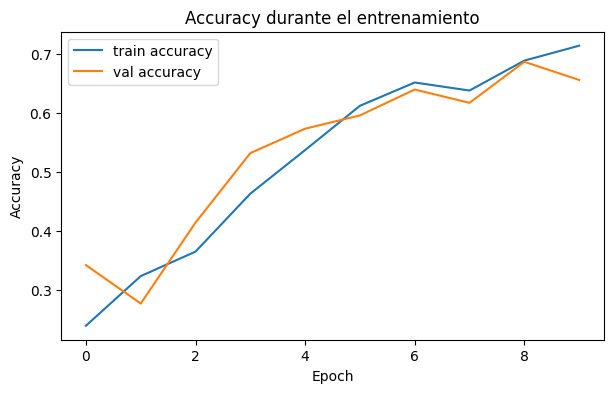

In [21]:
plt.figure(figsize=(7, 4))
plt.plot(history.history["accuracy"], label="train accuracy")
plt.plot(history.history["val_accuracy"], label="val accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy durante el entrenamiento")
plt.legend()
plt.show()

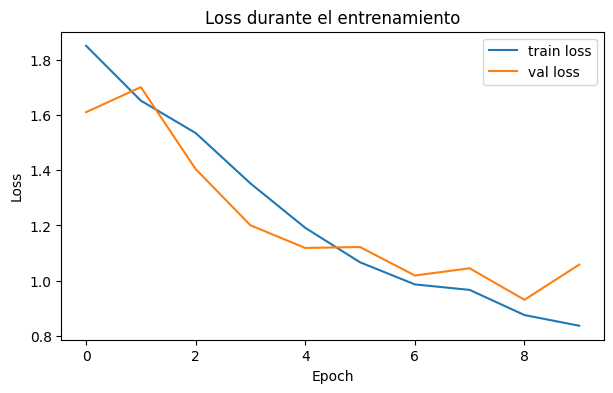

In [22]:
plt.figure(figsize=(7, 4))
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss durante el entrenamiento")
plt.legend()
plt.show()

## 8. Evaluación rápida

In [23]:
val_loss, val_acc = model.evaluate(val_spectrogram_ds, verbose=0)

print("Validation loss:", round(val_loss, 4))
print("Validation accuracy:", round(val_acc, 4))

Validation loss: 1.0582
Validation accuracy: 0.6556


## 9. Algunas predicciones

In [24]:
for spec_batch, label_batch in val_spectrogram_ds.take(1):
    y_prob = model.predict(spec_batch, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)

    for i in range(5):
        print(f"Ejemplo {i+1}:")
        print("  Predicción :", label_names[y_pred[i]])
        print("  Etiqueta real:", label_names[label_batch[i]])
        print()

Ejemplo 1:
  Predicción : up
  Etiqueta real: up

Ejemplo 2:
  Predicción : yes
  Etiqueta real: yes

Ejemplo 3:
  Predicción : stop
  Etiqueta real: stop

Ejemplo 4:
  Predicción : stop
  Etiqueta real: stop

Ejemplo 5:
  Predicción : left
  Etiqueta real: go



## 10. Conclusión

En este notebook vimos una aplicación de `LSTM` a audio.

La idea central fue:

- representar el audio como espectrograma,
- interpretar el espectrograma como secuencia,
- y usar una `LSTM` para clasificar.

Esto muestra que los modelos secuenciales no se limitan al texto: también pueden aplicarse a señales de audio.

## Bonus opcional: comparar con GRU

Como extensión, podemos reemplazar la capa `LSTM` por una capa `GRU`.

In [25]:
gru_model = keras.Sequential([
    layers.Input(shape=input_shape),
    layers.GRU(64),
    layers.Dense(64, activation="relu"),
    layers.Dense(num_classes, activation="softmax")
])

gru_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

gru_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        37,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,120 (164.53 KB)

 Trainable params: 42,120 (164.53 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
history_gru = gru_model.fit(
    train_spectrogram_ds,
    validation_data=val_spectrogram_ds,
    epochs=10,
    verbose=1
)

Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.1933 - loss: 1.9562 - val_accuracy: 0.2288 - val_loss: 1.8058
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.2955 - loss: 1.7027 - val_accuracy: 0.3794 - val_loss: 1.5679
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.4608 - loss: 1.3210 - val_accuracy: 0.5525 - val_loss: 1.1430
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.6531 - loss: 0.9409 - val_accuracy: 0.6919 - val_loss: 0.8381
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.7428 - loss: 0.7305 - val_accuracy: 0.7487 - val_loss: 0.7476
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.7873 - loss: 0.6097 - val_accuracy: 0.7956 - val_loss: 0.5927
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.8259 - loss: 0.5142 - val_accuracy: 0.7800 - val_loss: 0.6186
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.8380 - loss: 0.4740 - val_accu

In [27]:
gru_val_loss, gru_val_acc = gru_model.evaluate(val_spectrogram_ds, verbose=0)

print("Validation loss (GRU):", round(gru_val_loss, 4))
print("Validation accuracy (GRU):", round(gru_val_acc, 4))

Validation loss (GRU): 0.485
Validation accuracy (GRU): 0.8431


## Bonus opcional 2: Bidirectional LSTM

También podemos procesar la secuencia en ambos sentidos usando `Bidirectional`.

In [28]:
bilstm_model = keras.Sequential([
    layers.Input(shape=input_shape),
    layers.Bidirectional(layers.LSTM(64)),
    layers.Dense(64, activation="relu"),
    layers.Dense(num_classes, activation="softmax")
])

bilstm_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

bilstm_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 128)            │        99,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 108,104 (422.28 KB)

 Trainable params: 108,104 (422.28 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
history_bilstm = bilstm_model.fit(
    train_spectrogram_ds,
    validation_data=val_spectrogram_ds,
    epochs=10,
    verbose=1
)

Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.3267 - loss: 1.6637 - val_accuracy: 0.3413 - val_loss: 1.6873
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.4709 - loss: 1.3525 - val_accuracy: 0.5113 - val_loss: 1.2650
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.5344 - loss: 1.1992 - val_accuracy: 0.5469 - val_loss: 1.1725
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.5302 - loss: 1.2530 - val_accuracy: 0.5437 - val_loss: 1.1868
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.6139 - loss: 1.0741 - val_accuracy: 0.5981 - val_loss: 1.0619
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.6547 - loss: 0.9502 - val_accuracy: 0.6581 - val_loss: 0.9831
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - accuracy: 0.6913 - loss: 0.8691 - val_accuracy: 0.6737 - val_loss: 0.9366
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.7028 - loss: 0.8721 - val_acc

In [30]:
bilstm_val_loss, bilstm_val_acc = bilstm_model.evaluate(val_spectrogram_ds, verbose=0)

print("Validation loss (BiLSTM):", round(bilstm_val_loss, 4))
print("Validation accuracy (BiLSTM):", round(bilstm_val_acc, 4))

Validation loss (BiLSTM): 0.9078
Validation accuracy (BiLSTM): 0.6694
